In [85]:
# Abrir el archivo en modo binario

with open('square_300Hz.txt', 'rb') as file:
    # Leer el contenido del archivo
    byte_data = file.read()

# Mostrar el contenido en formato hexadecimal
hex_representation = byte_data.hex()

# Mostrar los primeros 100 caracteres de la representación hexadecimal (si el archivo es grande)
print(hex_representation[:100])


cd93cce2ccbeccc2cceeccedcdddcef5d09dd19ed2bad3e5d4f4d5e9c699e6d9e7d7a887a8c9a955a9f2aa92ab10aaf89026


In [86]:
fs = 8000000/512
T = 1/fs


In [87]:
# Agrupar los caracteres hexadecimales en bloques de 4 caracteres
grouped_hex = [hex_representation[i:i+4] for i in range(0, len(hex_representation), 4)]

# Mostrar el resultado
print(grouped_hex[:10])  # Muestra los primeros 10 grupos


['cd93', 'cce2', 'ccbe', 'ccc2', 'ccee', 'cced', 'cddd', 'cef5', 'd09d', 'd19e']


In [88]:
def generate_array(N, T):
    return [i * T for i in range(N)]

N = len(grouped_hex)  # Tamaño del array
X = (N - 1) * T  # Valor máximo alcanzado

time_array = generate_array(N, T)
print(time_array)

[0.0, 6.4e-05, 0.000128, 0.000192, 0.000256, 0.00031999999999999997, 0.000384, 0.000448, 0.000512, 0.000576, 0.0006399999999999999, 0.000704, 0.000768, 0.000832, 0.000896, 0.0009599999999999999, 0.001024, 0.001088, 0.001152, 0.0012159999999999999, 0.0012799999999999999, 0.001344, 0.001408, 0.001472, 0.001536, 0.0015999999999999999, 0.001664, 0.001728, 0.001792, 0.001856, 0.0019199999999999998, 0.001984, 0.002048, 0.0021119999999999997, 0.002176, 0.00224, 0.002304, 0.002368, 0.0024319999999999997, 0.002496, 0.0025599999999999998, 0.002624, 0.002688, 0.0027519999999999997, 0.002816, 0.0028799999999999997, 0.002944, 0.003008, 0.003072, 0.003136, 0.0031999999999999997, 0.003264, 0.003328, 0.003392, 0.003456, 0.0035199999999999997, 0.003584, 0.0036479999999999998, 0.003712, 0.003776, 0.0038399999999999997, 0.003904, 0.003968, 0.004032, 0.004096, 0.00416, 0.0042239999999999995, 0.004288, 0.004352, 0.004416, 0.00448, 0.004543999999999999, 0.004608, 0.004672, 0.004736, 0.0048, 0.00486399999999

In [89]:
# Convertir cada bloque hexadecimal en binario
grouped_bin = [bin(int(group, 16))[2:].zfill(16) for group in grouped_hex]

# Mostrar los primeros 10 valores binarios
print(grouped_bin[:10])


['1100110110010011', '1100110011100010', '1100110010111110', '1100110011000010', '1100110011101110', '1100110011101101', '1100110111011101', '1100111011110101', '1101000010011101', '1101000110011110']


In [90]:
# Convertir cada bloque hexadecimal a un número sin signo (uint16_t)
grouped_uint16 = [int(group, 16) & 0xFFFF for group in grouped_hex]

# Mostrar los primeros 10 valores uint16_t
print(grouped_uint16[:10])


[52627, 52450, 52414, 52418, 52462, 52461, 52701, 52981, 53405, 53662]


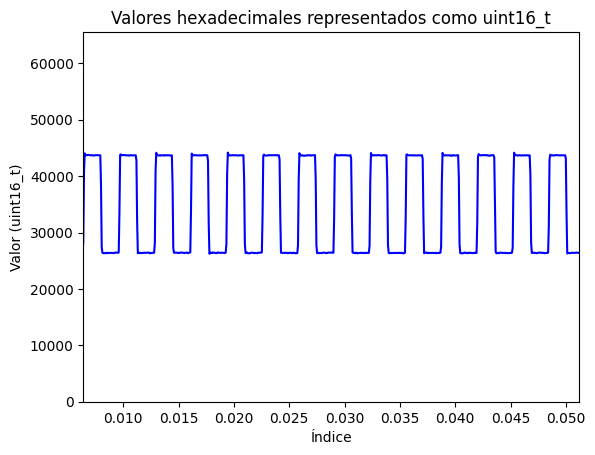

In [91]:
import matplotlib.pyplot as plt

plt.plot(time_array, grouped_uint16, linestyle='-', color='b')

# Etiquetas
plt.xlabel('Índice')
plt.ylabel('Valor (uint16_t)')
plt.title('Valores hexadecimales representados como uint16_t')
plt.ylim(0, 65536)  # Limitar el eje Y entre 0 y 65536 (como el rango de uint16_t)
plt.xlim(time_array[0], time_array[-1])  # Ajustar X al rango de result_array
plt.xlim(time_array[100], time_array[800])  # Ajustar X al rango de result_array
# Mostrar la gráfica
plt.show()